# ARGUS-FEDER — How does helium affect deuterium retention in tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question and three follow-ups. The questions are typed in plain English into an
`%%ask` cell. The agent decides what to look up, writes and runs its own code,
and reports back.

**Who wrote what.** This introduction and the short note above each question are
written by us, at SDSC. Everything inside and below an `%%ask` cell is the
agent's own: the steps it took, the code it wrote, the figures and the answer.
The questions themselves were written with Greg Sinclair and Amy Zheng, whose
group produced the data.

## The question

A burning plasma makes helium as well as consuming hydrogen isotopes, so the
tungsten facing one is tungsten that already carries a helium layer. Whether
that layer then holds more fuel or less is a first-order question for a reactor,
because deuterium and tritium held in the wall are both a safety limit and an
economic one.

The delivery this notebook works from was built to ask exactly that. Tungsten
coupons were pre-exposed to helium in the PISCES-A linear device at two
temperatures, mounted on the DiMES probe alongside coupons that were not, and
exposed together to real DIII-D discharges. Retention was measured afterwards by
three laboratory techniques.

The question is asked plainly first. The follow-ups then press on the two places
where a single number could mislead: which technique produced it, and which
plasma the coupon saw. The last question asks what the data cannot support.


In [ ]:
%reset

## 1 — The question, as asked

Put plainly, the way it would be asked in a meeting, with no constraint on how
it should be answered.


I’ll consult the materials and literature workflows, query the relevant measurements and papers, then synthesize the helium effect with documented evidence.

I’m reading both matching workflows and the existing materials learnings before writing query code.

The workflows require discovering quantities, design cells, delivery notes, and attached-paper passages before comparing helium-treated tungsten with controls.

I’m checking the working directory so new scripts and evidence files use unique names without overwriting prior work.

I’m writing a discovery script that batches samples, quantities, design, exposures, observations, and provider notes into one text-readable JSON file.

...

The computed ratios are internally consistent and preserve method-specific units and uncertainties; I’m beginning the required final audit.

I’m listing the working directory to confirm every script, source extract, CSV, JSON, and chart remains available for inspection.

I’m confirming the sole edit-and-retry lesson was persisted before closing, as required by the learnings protocol.

The audit confirms all outputs exist, no image was opened, and the only retry lesson is recorded; I’m completing the report step.

**Short answer** : Helium does not have a single, universal effect on deuterium retention in tungsten. A helium-pretreated surface can impede deuterium uptake through a near-surface nanobubble layer, but in these measurements the outcome depended strongly on helium-exposure temperature and the subsequent plasma regime: retention decreased by about **69%** in one condition but increased by as much as **85%** in another.

## What the tungsten samples show

These samples were pre-exposed in PISCES to 70 eV helium at either 600 K or 800 K, with fluences of $1.0\times10^{25}$ and $1.2\times10^{25}\ \mathrm{m^{-2}}$, respectively. They were then exposed to deuterium plasmas in either DIII-D H-mode or L-mode.

The provider identifies NRA as the most trustworthy retention method. Summing its reported surface and subsurface bands gives the following comparison:

| Subsequent plasma | Helium pretreatment | NRA retention, 0–3 µm ($10^{15}$ atoms cm$^{-2}$) | NRA change from no-He control | ERDA retention ($10^{15}$ atoms cm$^{-2}$) | ERDA change |
|---|---:|---:|---:|---:|---:|
| H-mode | None | 2.098 | Reference | $1.160 \pm 0.063$ | Reference |
| H-mode | 800 K | 0.652 | **−68.9%** | $0.668 \pm 0.048$ | **−42.4%** |
| H-mode | 600 K | 2.455 | **+17.0%** | $1.470 \pm 0.062$ | **+26.7%** |
| L-mode | None | 2.657 | Reference | $1.470 \pm 0.071$ | Reference |
| L-mode | 800 K | 2.960 | **+11.4%** | $2.000 \pm 0.083$ | **+36.1%** |
| L-mode | 600 K | 4.917 | **+85.1%** | $2.400 \pm 0.091$ | **+63.3%** |

Thus:

- **Clear suppression occurred only for 800 K helium pretreatment followed by H-mode exposure.** NRA measured approximately one-third of the control inventory, and ERDA independently measured about 58% of the control.
- **The 600 K helium pretreatment increased retention in both plasma regimes.**
- **In L-mode, helium shifted the depth distribution as well as the total.** At 800 K, NRA found 34.5% more D in the first 0.5 µm but 58.9% less from 0.5–3 µm, leaving a modest 11.4% net increase. At 600 K, the surface band increased by 121%, while the subsurface band decreased by 24.4%, producing an 85.1% total increase.
- The depth-resolved LAMS measurements are available, but the provider classifies LAMS as experimental and its uncertainties are frequently comparable to or larger than the measured values. They should not outweigh NRA or ERDA.


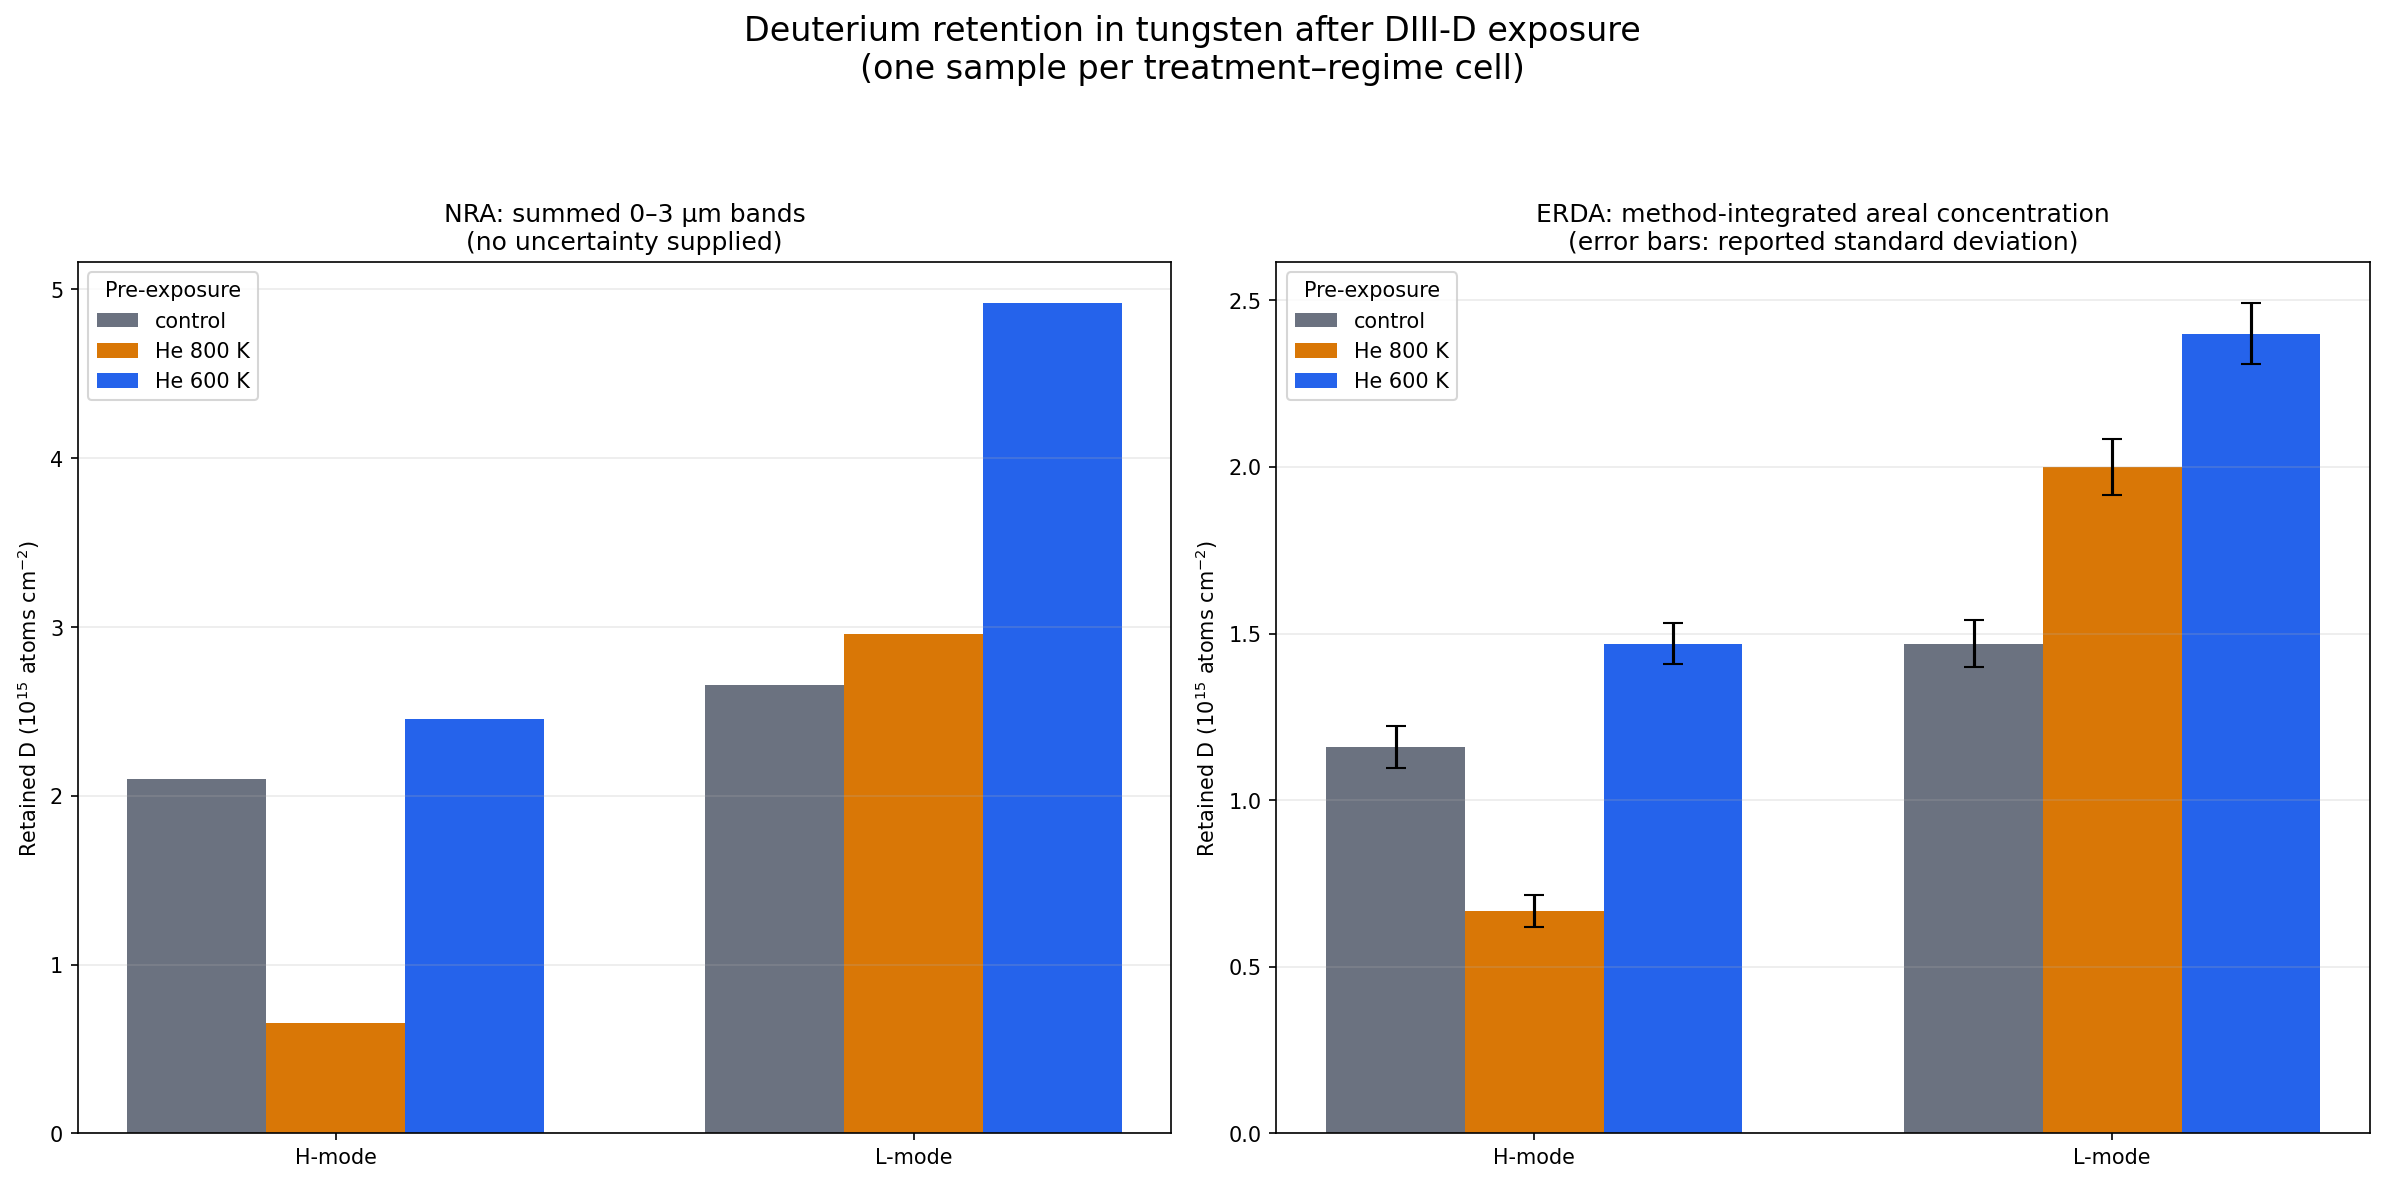

## Physical interpretation

Baldwin and Doerner explain the commonly observed **helium-induced reduced-inventory effect** as a near-surface transport phenomenon:

1. **Helium has very low solubility in tungsten.** Implanted He therefore precipitates near its stopping range and forms nanoscale bubbles.
2. At fusion-relevant fluence, these bubbles can form an approximately 30 nm affected layer. The paper reports that this behavior becomes established around a He fluence of $10^{25}\ \mathrm{m^{-2}}$, comparable to the &#36;1.0&#36;–$1.2\times10^{25}\ \mathrm{m^{-2}}$ pretreatments used for these samples.
3. The affected layer can act as a **permeation barrier** , altering deuterium diffusivity, solubility, and migration energy. The modeling found that simple loss of tungsten volume through bubble porosity was too weak to explain the measured barrier.
4. Increased recycling or a reduction in the D flux that actually penetrates the surface was also needed to reproduce the reduced inventory. Deuterium is not simply stored inside the He bubbles; the cited molecular-dynamics result instead indicates that D is rapidly excluded from them.

Baldwin and Doerner therefore concluded that **altered near-surface transport and altered recycling both contribute** to helium-induced reductions in hydrogen-isotope retention. Their paper also reports a prior experiment in which helium lowered rear-surface D permeation by roughly 90% at 800 K.

That mechanism provides a strong explanation for the 800 K/H-mode reduction observed here. It does **not** , by itself, establish why the other conditions produced increases. The present measurements indicate that helium-created defects and surface restructuring can either inhibit penetration or redistribute and enhance trapping, depending on how that modified layer interacts with the later plasma exposure.

## Important limits

- Every treatment–regime design cell contains **one coupon** , so treatment effects cannot be separated statistically from coupon-to-coupon variation.
- NRA carries no numerical uncertainty column in this delivery; its provider-assigned reliability does not imply that uncertainty is zero.
- Surface or bulk sample temperature during the later DIII-D exposure was not measured.
- H-mode and L-mode had different deuterium-plasma conditions, including impact energy, flux, fluence, and heat flux. Comparisons of helium treatments are strongest **within** a regime, not between H-mode and L-mode.
- The attached Baldwin–Doerner paper supplies mechanism and context from its own PISCES experiments; it is not an additional measurement of these DIII-D-exposed coupons.

## Reference

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

## Data files

- [helium_deuterium_retention_summary.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_retention_summary.csv) — method-specific retention values, controls, ratios, percentage changes, and reported ERDA uncertainties.
- [helium_deuterium_lams_profiles.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_lams_profiles.csv) — all 90 depth-resolved LAMS points and their uncertainties.
- [helium_deuterium_exposure_conditions.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_exposure_conditions.csv) — PISCES helium and DIII-D deuterium exposure conditions.
- [helium_deuterium_literature_evidence.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_literature_evidence.csv) — retrieved paper passages with sections, pages, and exact citation.
- [helium_deuterium_focused_query.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_focused_query.json) — raw focused results for NRA, ERDA, LAMS, exposure conditions, documents, and literature.
- [helium_deuterium_materials_discovery.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/helium_deuterium_materials_discovery.json) — complete quantity, sample, design, delivery-note, exposure, and observation discovery output.

In [2]:
%%ask
How does the presence of helium affect the retention of deuterium in tungsten?

## 2 — Does the answer depend on the measurement technique?

Three techniques measured retention on these coupons, and they do not all report
the same quantity or carry the same uncertainty.


I’ll compare NRA, ERDA, and LAMS on matched samples, quantify agreement and uncertainty, and preserve the underlying values in auditable data files.

I’m reading the materials skill to follow its dataset-specific query and interpretation rules.

The skill requires searching attached papers for every materials answer, so I’m consulting the literature retrieval instructions next.

The instructions confirm that every retention method must be reported, depth profiles require `profiles()`, and instrumental error must be separated from unreplicated sample variability.

I’m listing the materials helper directory to identify the exact importable modules needed for a single, reproducible batch query.

...

I’m listing the working directory to confirm the CSV, JSON, scripts, and chart files exist without opening any image.

All requested files are present, and no image was read; I’m checking the compact uncertainty table used for the final interpretation.

The uncertainty table confirms ERDA’s reported relative errors are 3.8–7.2%, while LAMS has a 95% median relative error and one-third of points exceed 100%.

Final audit found no edit-and-retry cycle, no unresolved execution error, and complete numerical provenance for every reported comparison.

**Bottom line** : The conclusion is robust to the two primary areal-density techniques, **NRA and ERDA** : both find that 800 K helium pretreatment reduces retention after H-mode exposure, while the other three helium–plasma combinations increase it. The size of the effect is technique-dependent, however, and the experimental LAMS depth profiles are too uncertain to establish most treatment effects independently; in L-mode they can even suggest a different direction.

## Comparison by technique

NRA and ERDA report values in atoms cm$^{-2}$, although they do not necessarily sample deuterium identically. LAMS instead reports concentration in APPM at ten depths, so it is primarily a depth-profile measurement rather than a directly comparable total inventory.

| Plasma regime | He pretreatment | NRA change, summed 0–3 µm | ERDA change | ERDA propagated uncertainty |
|---|---:|---:|---:|---:|
| H-mode | 800 K | **−68.9%** | **−42.4%** | $\pm 5.2$ percentage points |
| H-mode | 600 K | **+17.0%** | **+26.7%** | $\pm 8.7$ percentage points |
| L-mode | 800 K | **+11.4%** | **+36.1%** | $\pm 8.7$ percentage points |
| L-mode | 600 K | **+85.1%** | **+63.3%** | $\pm 10.0$ percentage points |

The propagated ERDA uncertainties are approximate one-standard-deviation values calculated as

$$
\sigma_r=r\sqrt{\left(\frac{\sigma_t}{t}\right)^2+
                    \left(\frac{\sigma_c}{c}\right)^2},
$$

where $r=t/c$ is the treated-to-control ratio. This assumes independent reported errors for the two coupons.


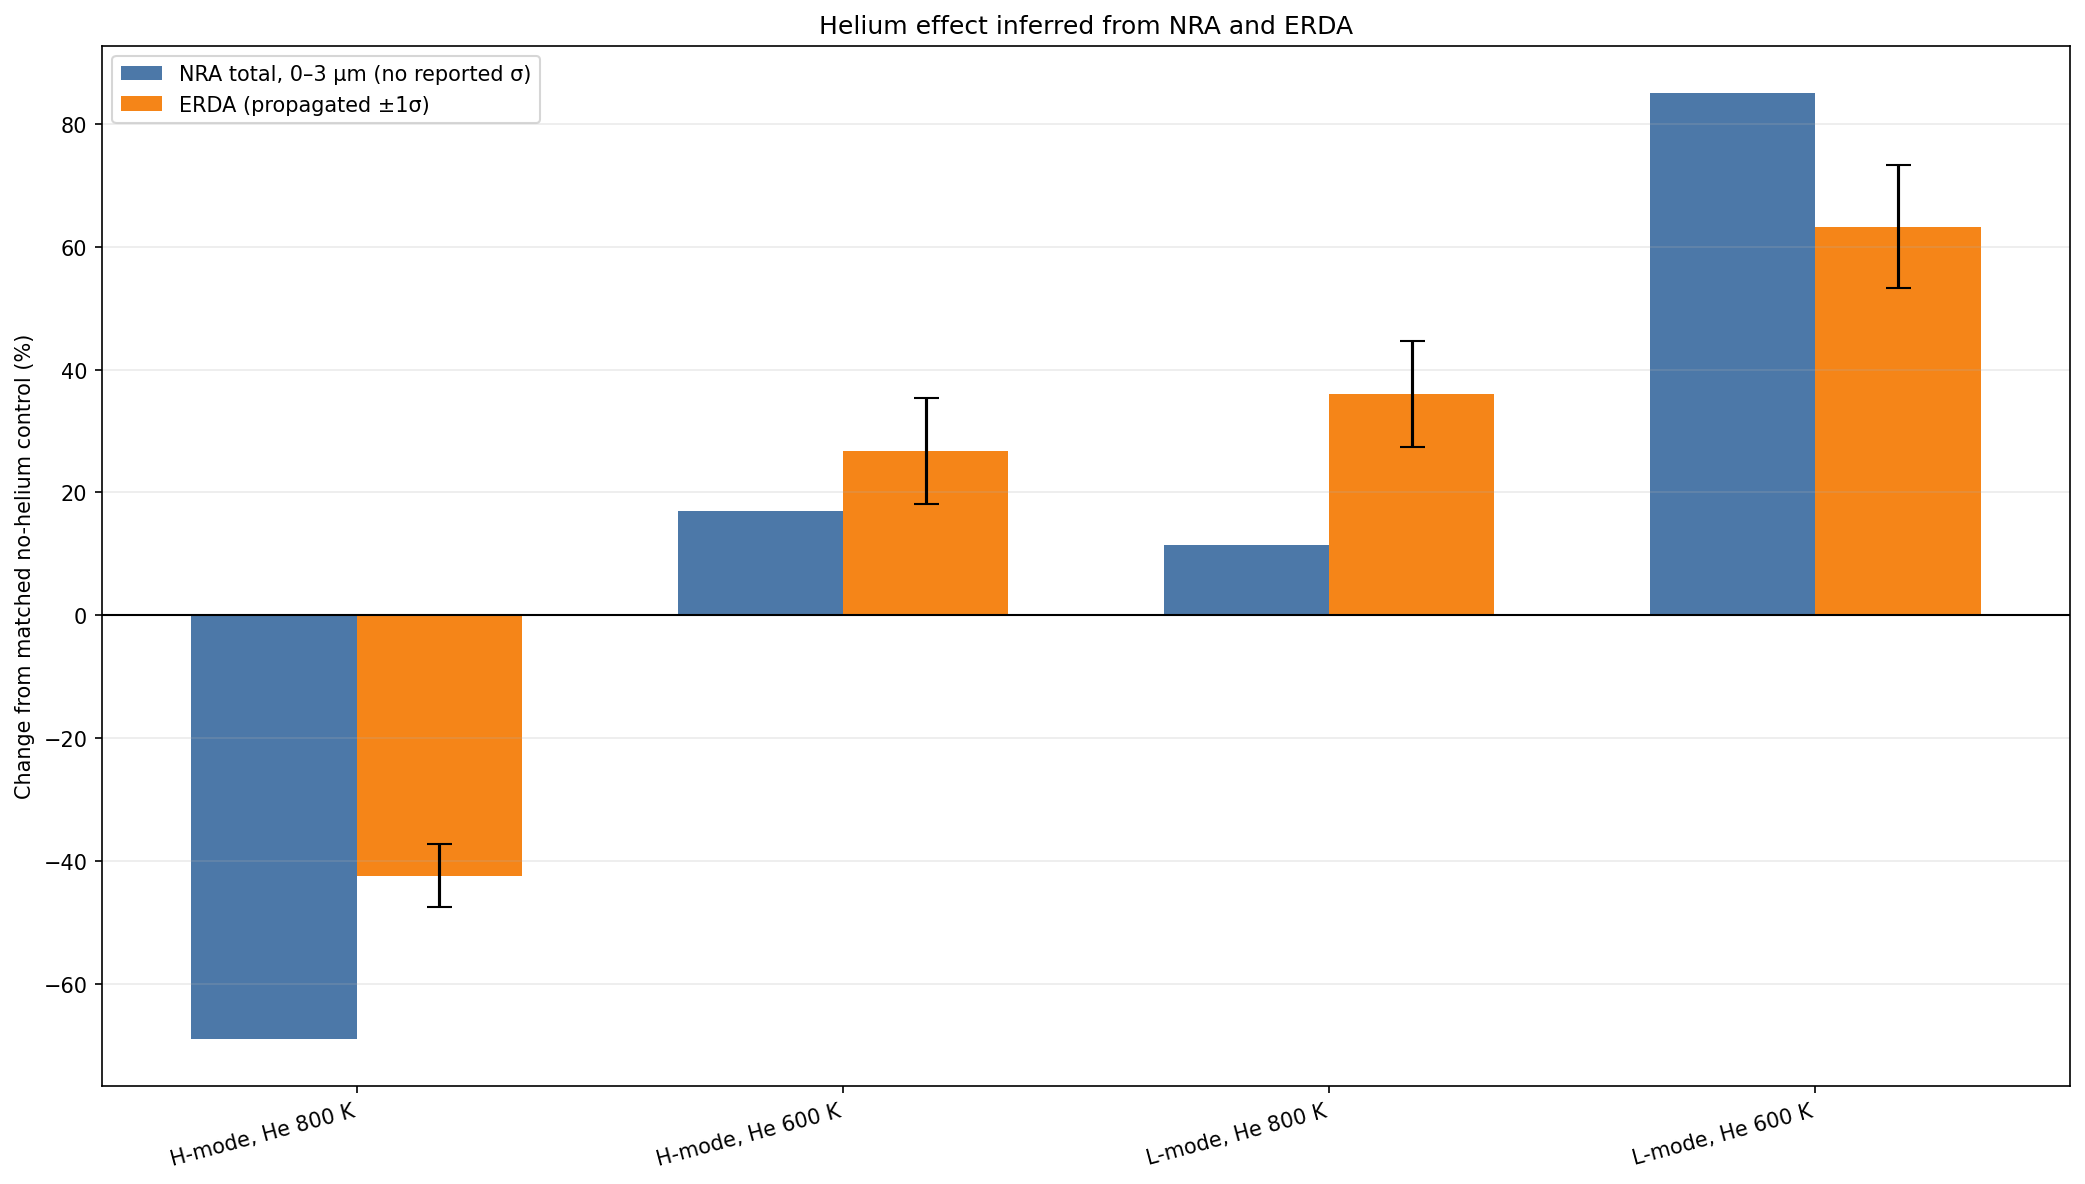

### NRA

NRA supplies two depth bands:

- surface: 0–0.5 µm;
- subsurface: 0.5–3 µm.

The provider ranks NRA as the **most trustworthy** method in this delivery. Its main advantage for interpretation is that it shows whether a change is concentrated near the surface or extends farther into the tungsten.

That matters particularly in L-mode:

- At 800 K, the NRA surface inventory rose **34.5%** , while the subsurface inventory fell **58.9%** . The summed change was only **+11.4%** .
- At 600 K, the surface inventory rose **121%** , while the subsurface inventory fell **24.4%** . The large surface increase drove the summed **+85.1%** result.

Thus, a technique or summary restricted to a different depth range could legitimately produce a different apparent helium effect.

The important NRA limitation is that **no numerical uncertainty was delivered** for any of its 18 depth-band measurements. That does not mean zero uncertainty. It means formal confidence intervals cannot be calculated from this delivery, so the relatively small NRA increases of 17.0% and 11.4% cannot be assigned statistical significance.

### ERDA

ERDA reports one areal-concentration result per DIII-D-exposed coupon and includes a numerical standard deviation. Its reported relative standard deviations are:

- **Minimum** : 3.8%;
- **Median** : 4.5%;
- **Maximum** : 7.2%.

Under independent-error propagation, the four treatment/control differences correspond nominally to approximately 3.5–8.1 combined measurement standard deviations. At the **instrumental-error level** , therefore, ERDA strongly supports all four measured differences.

However, that is not the same as demonstrating a reproducible treatment effect. There is only one coupon in each treatment–regime cell, so these nominal standard-deviation comparisons do not include coupon-to-coupon variation.

NRA and ERDA also differ substantially in absolute inventory. Across the six DIII-D-exposed coupons, the summed NRA result is approximately **0.98–2.05 times** the ERDA result. The near equality occurs for the 800 K/H-mode coupon; most other NRA totals are appreciably larger. This method-to-method spread is much greater than ERDA’s reported 4–7% random uncertainty and indicates that systematic differences such as depth sensitivity, calibration, or the precise measurement definition dominate the absolute cross-technique comparison.

Therefore, it is more defensible to compare **each technique’s treated coupon with its matched control** than to average NRA and ERDA into one retention value.

## What LAMS adds—and why it is less decisive

LAMS provides ten depth-resolved values per coupon in APPM, each with a reported uncertainty. It does not provide the same areal-density quantity as NRA and ERDA, so it should not be treated as a third interchangeable total-retention measurement.

Its uncertainties are large:

- **Median pointwise relative uncertainty** : 95%;
- **Range over DIII-D-exposed coupons** : 47–199%;
- **Points whose standard deviation equals or exceeds the measured value** : 33%.


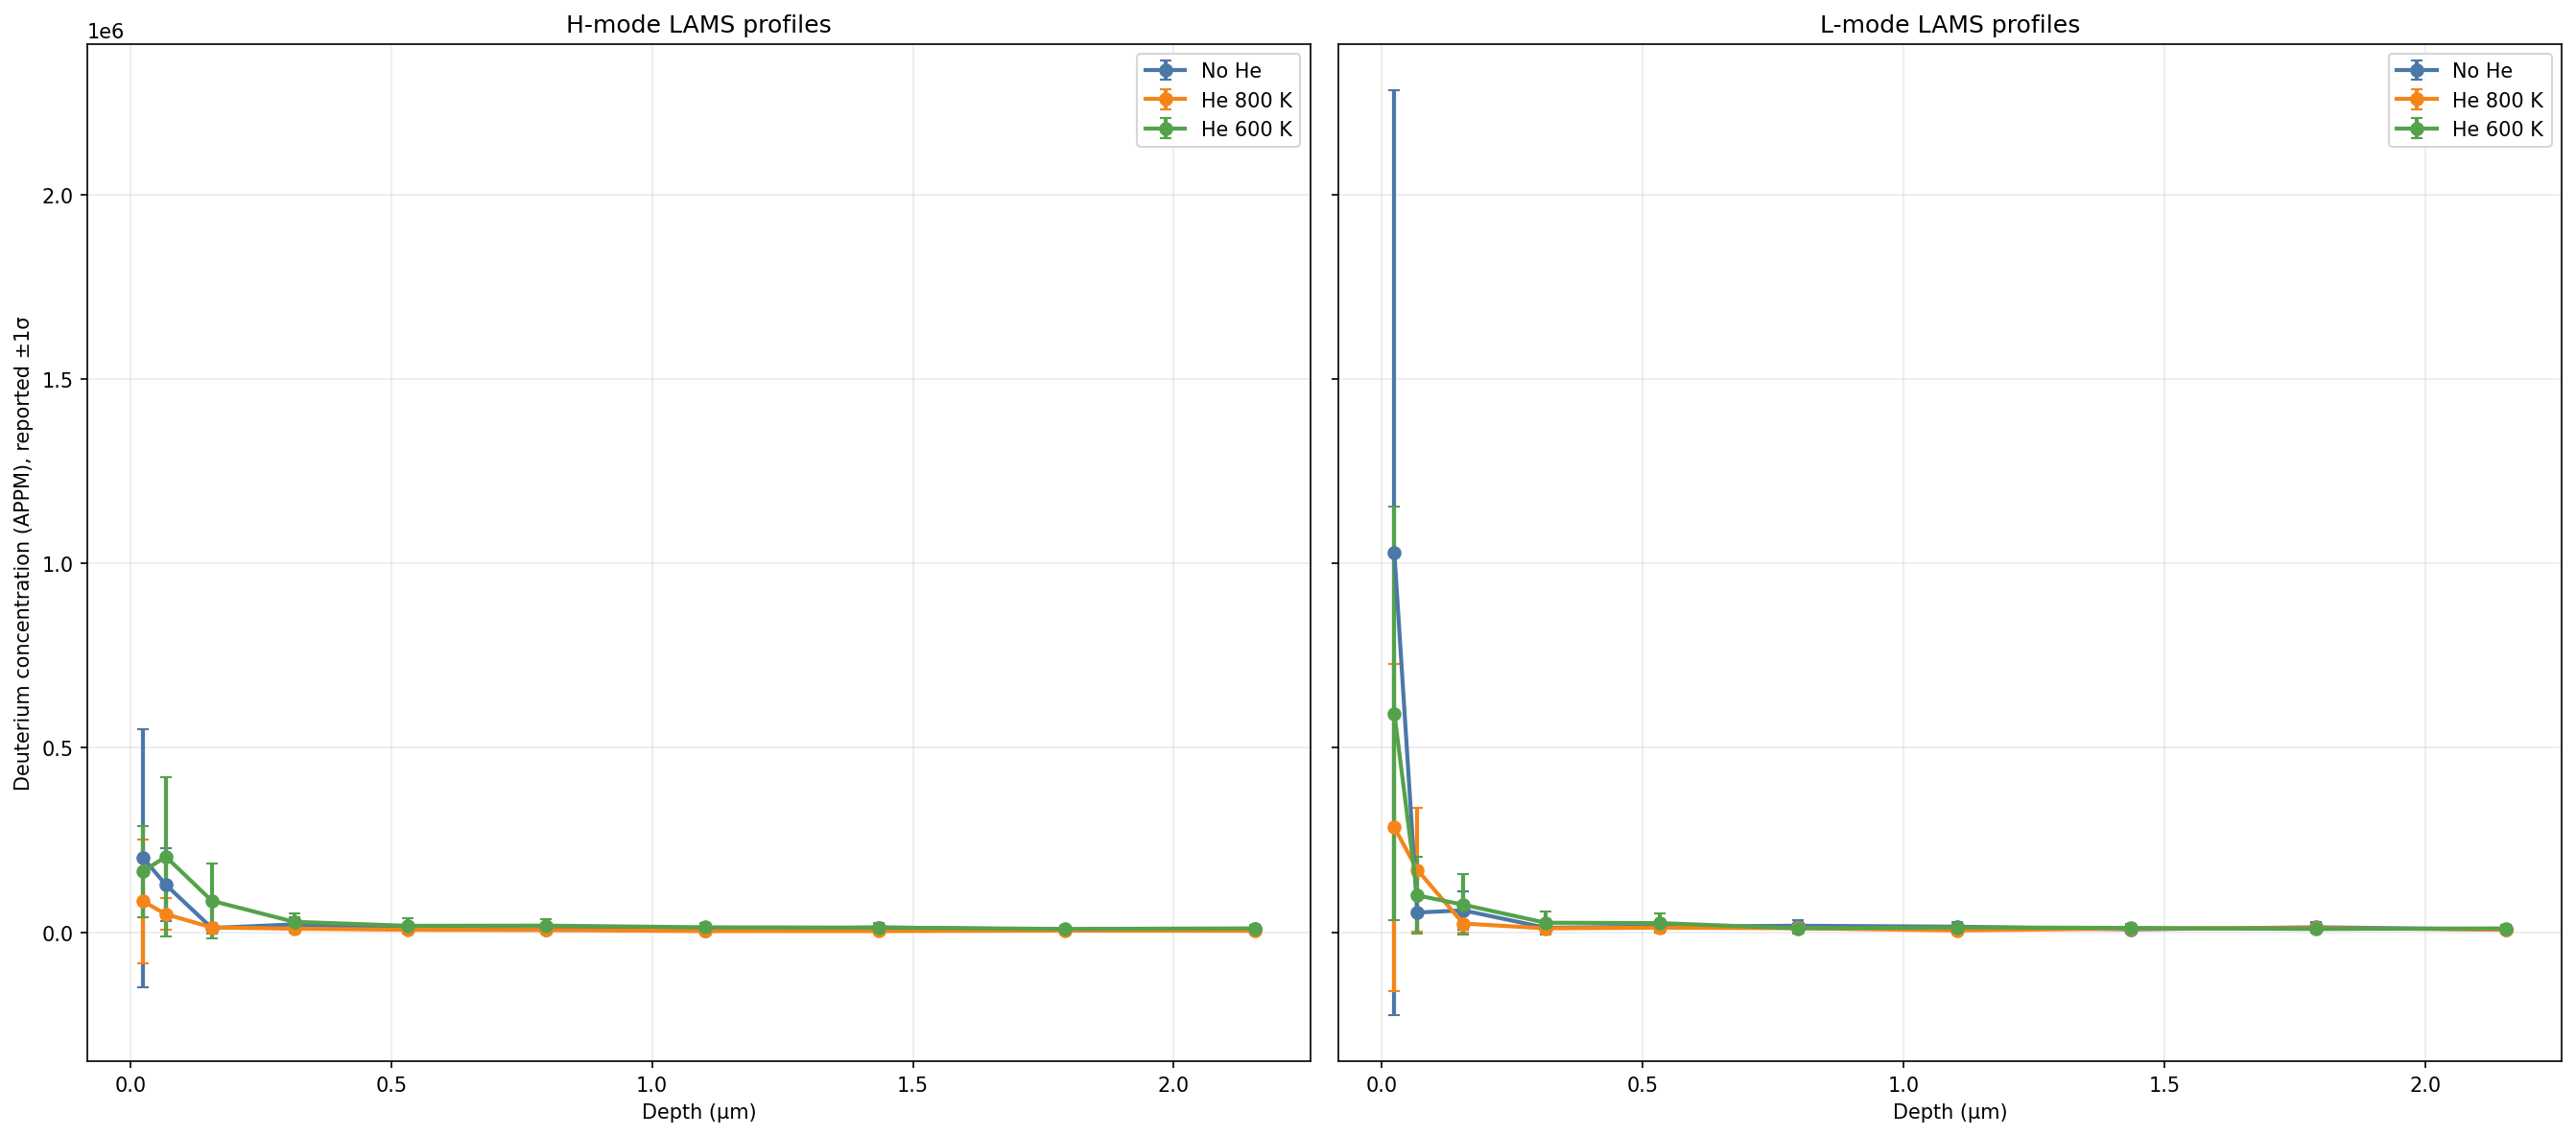

A trapezoidal integration of each LAMS profile provides a descriptive profile-area proxy. It is not an areal-density measurement, and the uncertainties below assume independent depth points:

| Plasma regime | He pretreatment | LAMS profile-area change | Approximate propagated uncertainty | Agreement with NRA/ERDA |
|---|---:|---:|---:|---|
| H-mode | 800 K | −50.5% | $\pm 24.8$ percentage points | Same direction |
| H-mode | 600 K | +68.2% | $\pm 88.7$ percentage points | Same direction, unresolved |
| L-mode | 800 K | −33.1% | $\pm 45.0$ percentage points | Opposite direction, unresolved |
| L-mode | 600 K | −3.7% | $\pm 61.2$ percentage points | Opposite direction, unresolved |

Across the four matched comparisons, only **one of 40 individual depth-point differences exceeded one combined standard deviation** , and none exceeded two. The LAMS profiles therefore provide suggestive information about depth redistribution but little independent evidence for the total-retention effect.

This is consistent with the provider’s explicit guidance: LAMS is experimental and should be treated as indicative, not allowed to outweigh NRA or ERDA where they disagree.

## Overall uncertainty assessment

There are three distinct forms of uncertainty here:

1. **Reported instrumental uncertainty**
   - ERDA quantifies it and it is relatively small.
   - LAMS quantifies it and it is large.
   - NRA does not quantify it in this delivery.

2. **Systematic technique uncertainty**
   - NRA and ERDA can differ by roughly a factor of two in absolute inventory.
   - LAMS reports a different quantity and depth representation.
   - These differences are not captured by the reported ERDA standard deviations.

3. **Experimental-design uncertainty**
   - Every treatment–regime cell contains only **one coupon** .
   - Consequently, instrumental precision cannot distinguish a helium-treatment effect from coupon-to-coupon variability.
   - Surface and bulk temperature during the later DIII-D exposure were not measured, adding another uncontrolled source of physical variability.

## Most defensible interpretation

- **Strongest result** : 800 K helium pretreatment followed by H-mode exposure lowers deuterium retention. NRA, ERDA, and the indicative LAMS profile all point in the same direction.
- **Reasonably supported result** : 600 K pretreatment increases retention in both H-mode and L-mode according to NRA and ERDA, although LAMS does not resolve those increases.
- **Technique-sensitive result** : The magnitude of every effect depends on the measurement method, and the modest 800 K/L-mode increase is particularly sensitive to depth weighting.
- **Not established statistically** : Because there is one coupon per experimental cell, none of these comparisons demonstrates population-level reproducibility, regardless of how small the ERDA instrumental errors are.

## Data files

- [retention_effects_by_technique.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_effects_by_technique.csv) — NRA surface, subsurface, and total effects plus ERDA effects and propagated uncertainties.
- [retention_values_by_technique.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_values_by_technique.csv) — coupon-level NRA and ERDA measurements and ERDA standard deviations.
- [retention_uncertainty_summary.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_uncertainty_summary.csv) — uncertainty coverage and relative-error summaries for all three techniques.
- [lams_profile_effect_summary.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lams_profile_effect_summary.csv) — depth-point agreement counts and integrated profile descriptors.
- [lams_profile_point_comparisons.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lams_profile_point_comparisons.csv) — all 40 matched LAMS depth comparisons with reported and propagated uncertainties.
- [retention_technique_analysis_summary.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_technique_analysis_summary.json) — machine-readable summary of the calculations.
- [retention_measurements_raw.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_measurements_raw.json) — raw NRA, ERDA, and LAMS query results plus workbook commentary.
- [retention_method_discovery.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_method_discovery.json) — discovered methods, sample design, provider guidance, document hits, and attached-literature search results.

In [3]:
%%ask
How does the answer depend on the retention measurement technique? Can you 
comment on the uncertainty in these measurements?

## 3 — Retention against the DIII-D plasma condition

The coupons were exposed in two confinement regimes. This asks for the effect of
that difference, in total and with depth, with the method dependence from the
previous question carried through.


I’ll compare matched L-mode and H-mode coupons within each helium pretreatment, quantify depth-resolved changes, assess method-dependent uncertainty, and save auditable results.

I’m reading the materials skill to use its authoritative dataset interface and preserve the provider’s method guidance.

I’m checking the d3d-materials learnings so known query and analysis pitfalls are avoided before writing code.

The skill confirms NRA has two depth bands, ERDA is scalar, LAMS is profiled, and each comparison must remain method-specific.

I’m reading the literature-search instructions because the materials workflow requires checking attached papers for every analysis.

...

I’m reading the NRA depth-band CSV to verify the most trusted technique’s near-surface and subsurface L–H changes.

I’m reading the LAMS profile-area summary to quantify its technique-specific direction and uncertainty without treating it as an areal-density total.

I’m reading the full 30-row LAMS comparison to identify where with depth the L-mode profile rises or falls and how large each uncertainty is.

Verification is complete: all outputs exist, tabular values match the query, and no script required an edit-and-retry cycle or learning update.

**Bottom line** : Relative to matched H-mode coupons, the L-mode coupons retained more deuterium according to both NRA and ERDA at every helium-pretreatment level. The increase was about **27% without helium** , but was much larger after helium pretreatment: **199–354% at 800 K** and **63–100% at 600 K** , depending on technique. NRA resolves these increases in both depth bands; LAMS suggests a less consistent depth response and is too uncertain to establish most L–H differences independently.

## DIII-D conditions being compared

The L-mode and H-mode exposures differed in several recorded conditions, not just confinement regime:

| Recorded condition | H-mode | L-mode | L-mode relative to H-mode |
|---|---:|---:|---:|
| Average heat flux | 0.72 MW m$^{-2}$ | 0.47 MW m$^{-2}$ | −34.7% |
| Average particle fluence | $6.7\times10^{22}$ m$^{-2}$ | $7.8\times10^{22}$ m$^{-2}$ | +16.4% |
| Average particle flux | $4.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | $7.5\times10^{21}$ m$^{-2}$ s$^{-1}$ | +66.7% |
| Exposure duration | 12.5 s | 10.0 s | −20.0% |
| Impact energy | 150 eV | 175 eV | +16.7% |
| $T_e$ | 27.9 eV | 40.8 eV | +46.2% |
| $n_e$ | $5.76\times10^{18}$ m$^{-3}$ | $7.35\times10^{18}$ m$^{-3}$ | +27.6% |

Thus, “L-mode versus H-mode” here means comparing two different exposure packages. The L-mode campaign had substantially greater particle flux, modestly greater fluence and impact energy, and lower heat flux. The resulting retention changes cannot be attributed uniquely to confinement mode itself.

## Total D retention: NRA and ERDA

The percentage change is defined as

$$
100\left(\frac{D_{\mathrm{L}}}{D_{\mathrm{H}}}-1\right).
$$

Values below are in $10^{15}$ atoms cm$^{-2}$. For NRA, “total” is the sum of the delivered 0–0.5 and 0.5–3 µm bands.

| Helium pretreatment | Technique | H-mode total | L-mode total | Absolute L−H change | L-mode change |
|---|---|---:|---:|---:|---:|
| None | NRA | 2.098 | 2.657 | +0.559 | **+26.6%** |
| None | ERDA | $1.160\pm0.063$ | $1.470\pm0.071$ | $+0.310\pm0.095$ | **$+26.7\%\pm9.2$ percentage points** |
| 800 K He | NRA | 0.652 | 2.960 | +2.308 | **+354.3%** |
| 800 K He | ERDA | $0.668\pm0.048$ | $2.000\pm0.083$ | $+1.332\pm0.096$ | **$+199.4\%\pm24.8$ percentage points** |
| 600 K He | NRA | 2.455 | 4.917 | +2.462 | **+100.3%** |
| 600 K He | ERDA | $1.470\pm0.062$ | $2.400\pm0.091$ | $+0.930\pm0.110$ | **$+63.3\%\pm9.2$ percentage points** |


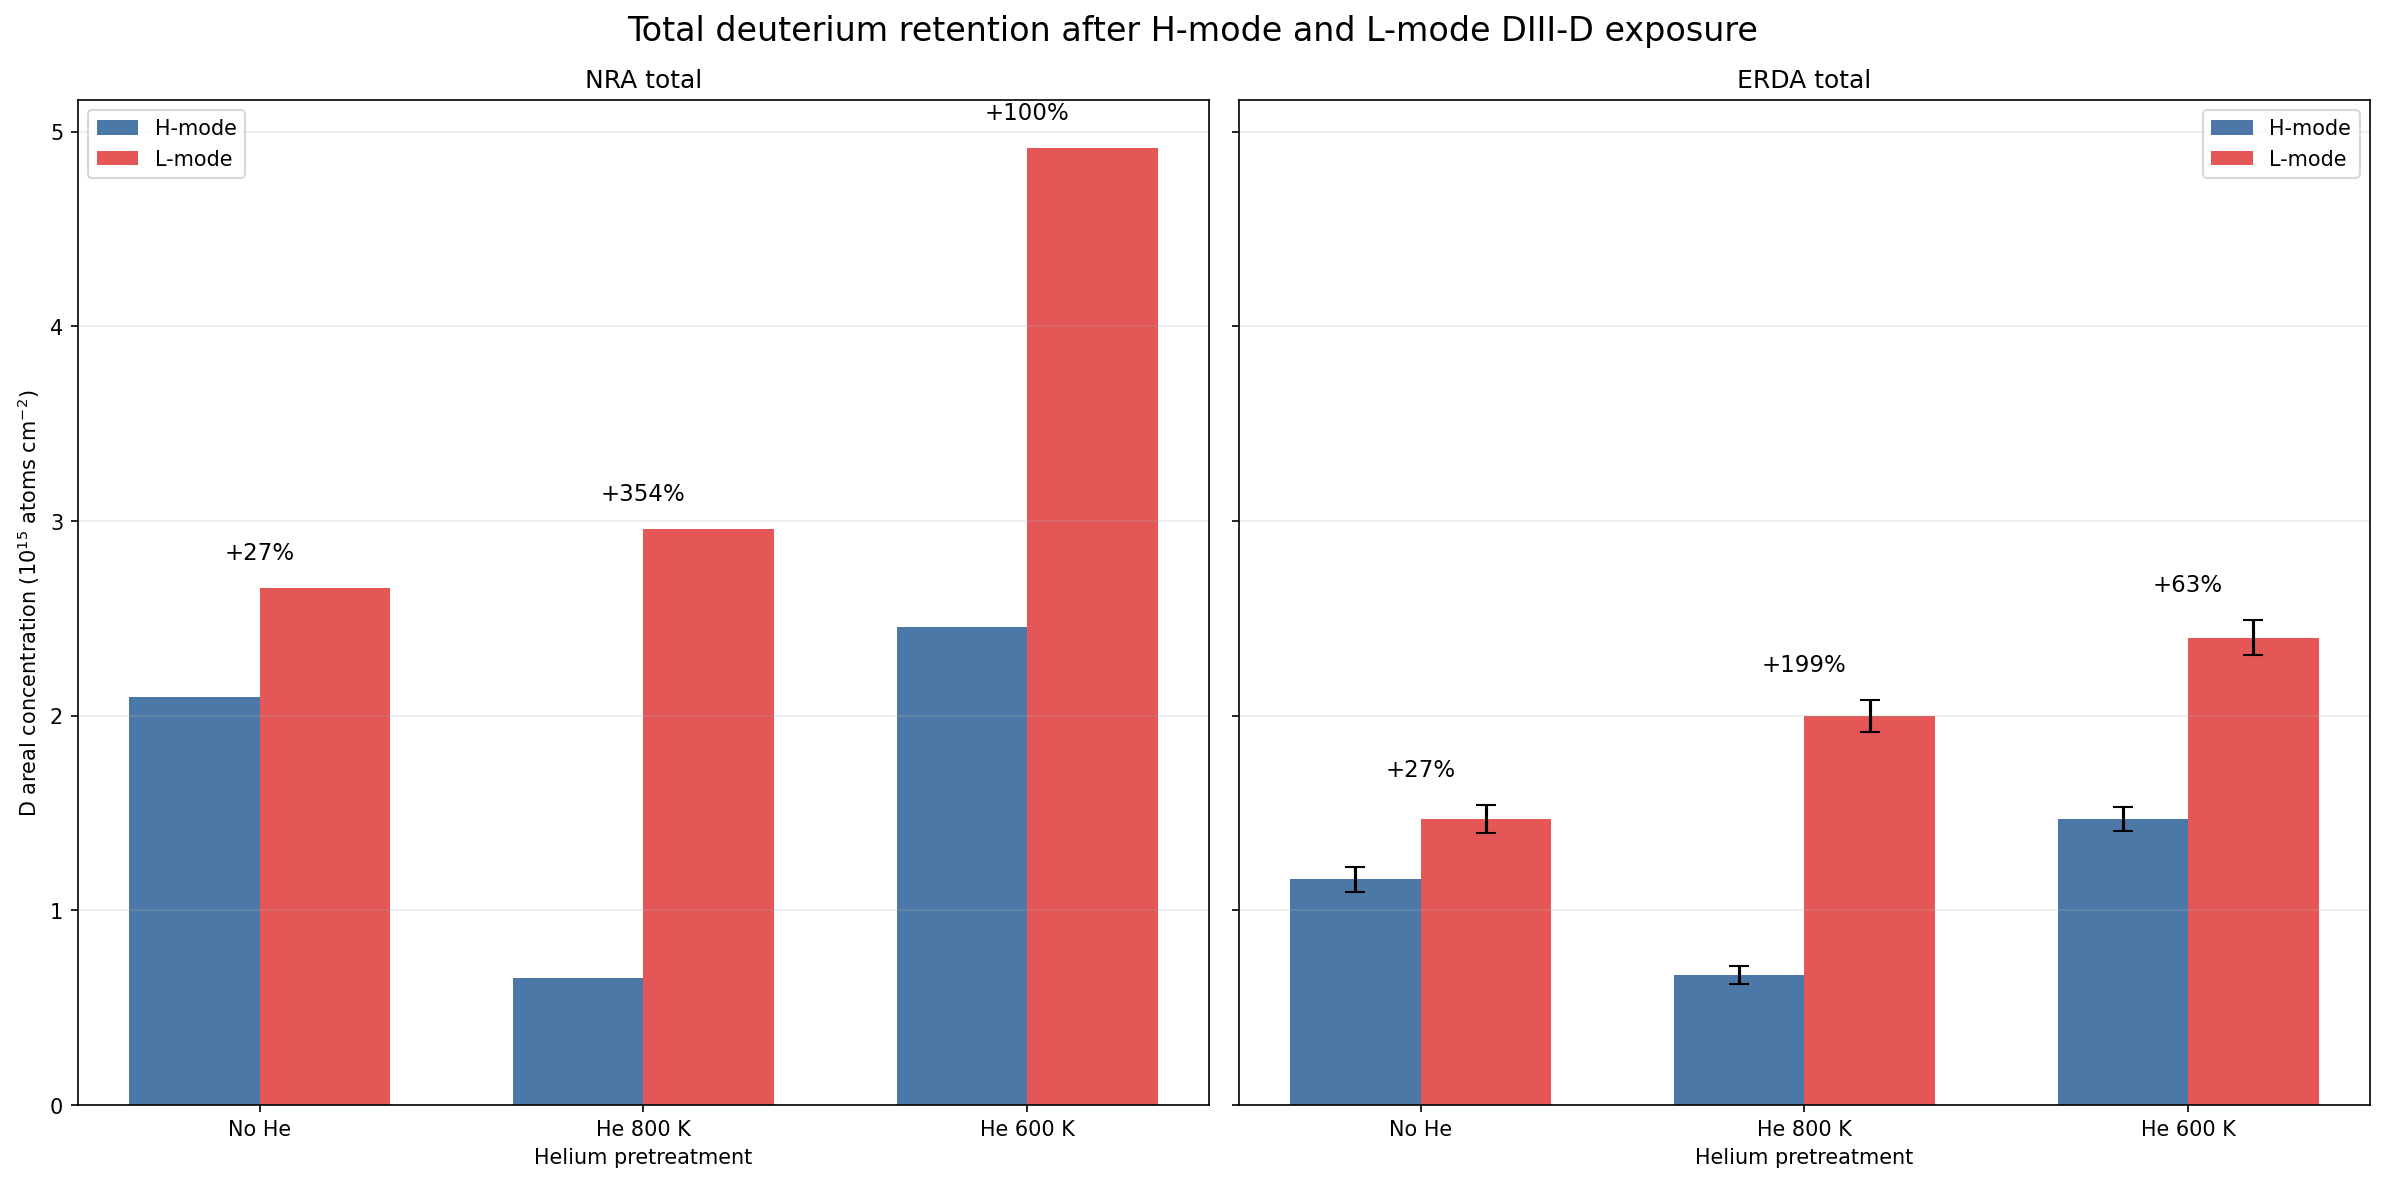

### Technique dependence of the total-retention result

The two areal-density techniques agree on the **direction** in all three matched comparisons:

- **No helium** : nearly identical relative changes—NRA gives +26.6% and ERDA gives +26.7%.
- **800 K helium pretreatment** : both show a large increase in L-mode, but NRA gives a much larger factor. The NRA L/H ratio is 4.54, versus 2.99 by ERDA.
- **600 K helium pretreatment** : both again show an increase, with an NRA L/H ratio of 2.00 versus 1.63 by ERDA.

The strongest technique sensitivity is therefore in the **magnitude** , not the sign. NRA indicates that the L-mode enhancement is especially large after 800 K helium pretreatment, while ERDA gives a smaller—but still substantial—increase.

The provider ranks **NRA as the most trustworthy technique** , so its result should lead the interpretation. NRA has no numerical uncertainty column in this delivery, however, and its apparent precision must not be inferred from that absence.

## NRA retention as a function of depth

NRA divides the retained D inventory into two broad depth bands:

| Helium pretreatment | NRA depth band | H-mode | L-mode | Absolute L−H change | L-mode change |
|---|---|---:|---:|---:|---:|
| None | Surface, 0–0.5 µm | 1.800 | 2.000 | +0.200 | **+11.1%** |
| None | Subsurface, 0.5–3 µm | 0.298 | 0.657 | +0.359 | **+120.5%** |
| 800 K He | Surface, 0–0.5 µm | 0.582 | 2.690 | +2.108 | **+362.2%** |
| 800 K He | Subsurface, 0.5–3 µm | 0.0696 | 0.270 | +0.2004 | **+287.9%** |
| 600 K He | Surface, 0–0.5 µm | 2.060 | 4.420 | +2.360 | **+114.6%** |
| 600 K He | Subsurface, 0.5–3 µm | 0.395 | 0.497 | +0.102 | **+25.8%** |

All NRA values in the table are in $10^{15}$ atoms cm$^{-2}$.


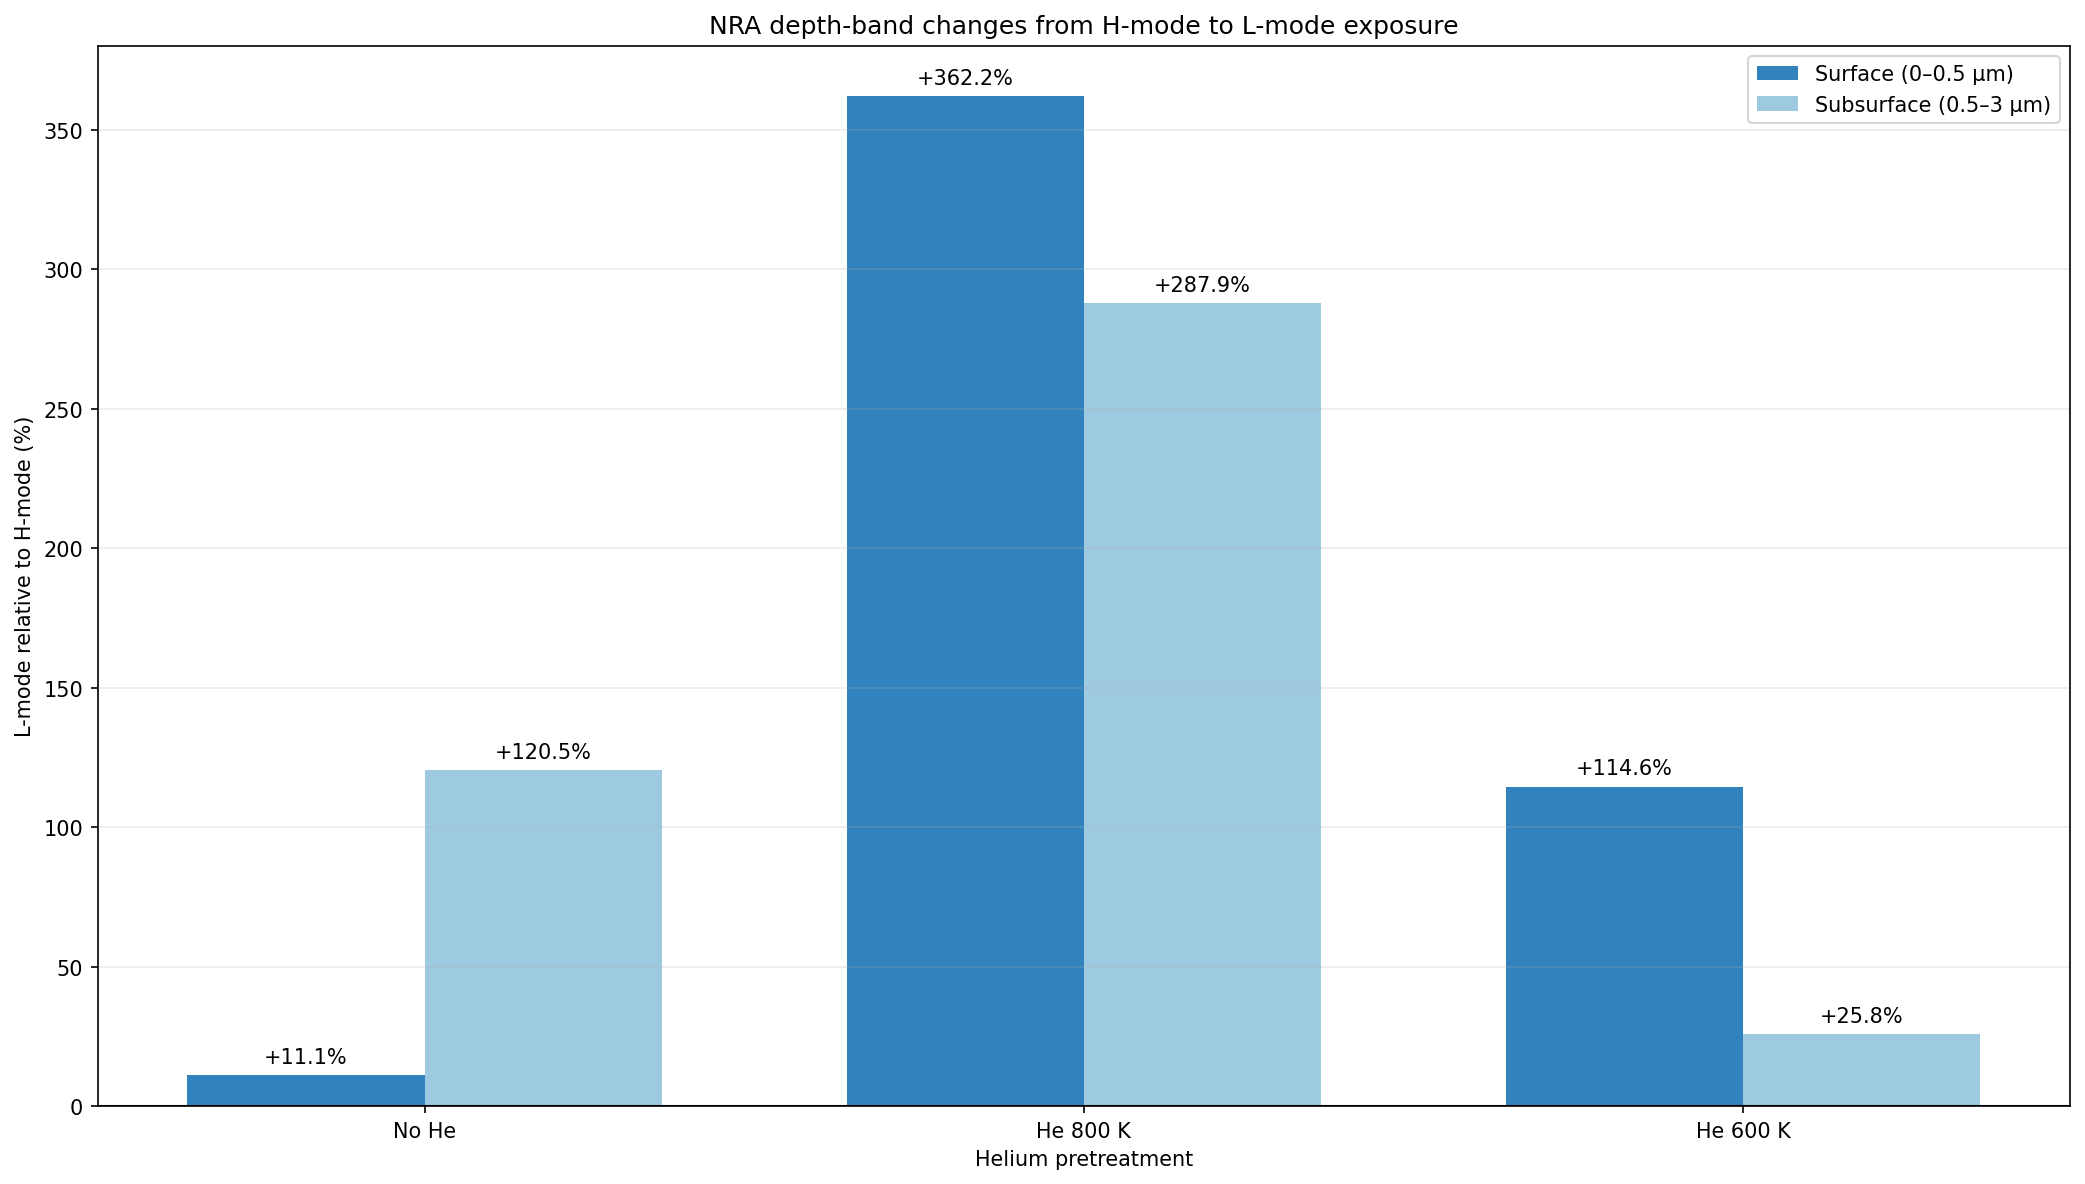

The depth distribution depends strongly on helium pretreatment:

- **No helium** : most of the absolute inventory remained within the first 0.5 µm, but the larger relative L-mode effect occurred deeper. The surface band rose only 11.1%, whereas the 0.5–3 µm band more than doubled.
- **800 K helium pretreatment** : L-mode produced a large increase in both bands. The absolute increase was dominated by the surface band, which rose by $2.108\times10^{15}$ atoms cm$^{-2}$.
- **600 K helium pretreatment** : the total increase was also surface-dominated. The 0–0.5 µm inventory rose 114.6%, while the 0.5–3 µm inventory rose only 25.8%.

Consequently, the total NRA increase does not represent one common depth response. Without helium, L-mode preferentially enhanced the relative subsurface inventory; after either helium pretreatment, the absolute enhancement was concentrated primarily within the first 0.5 µm.

## LAMS depth profiles

LAMS reports concentration in APPM at ten depths from 0.024 to 2.155 µm. It does **not** report the same areal-density quantity as NRA and ERDA, so its profile cannot be added directly to either total.

The pointwise behavior was:

| Helium pretreatment | Depth points with L > H | Range of pointwise L-mode changes | Points differing by more than one combined $\sigma$ |
|---|---:|---:|---:|
| None | 6 of 10 | −58.4% to +410.2% | 0 of 10 |
| 800 K He | 10 of 10 | +9.4% to +245.1% | 0 of 10 |
| 600 K He | 3 of 10 | −51.2% to +259.3% | 0 of 10 |


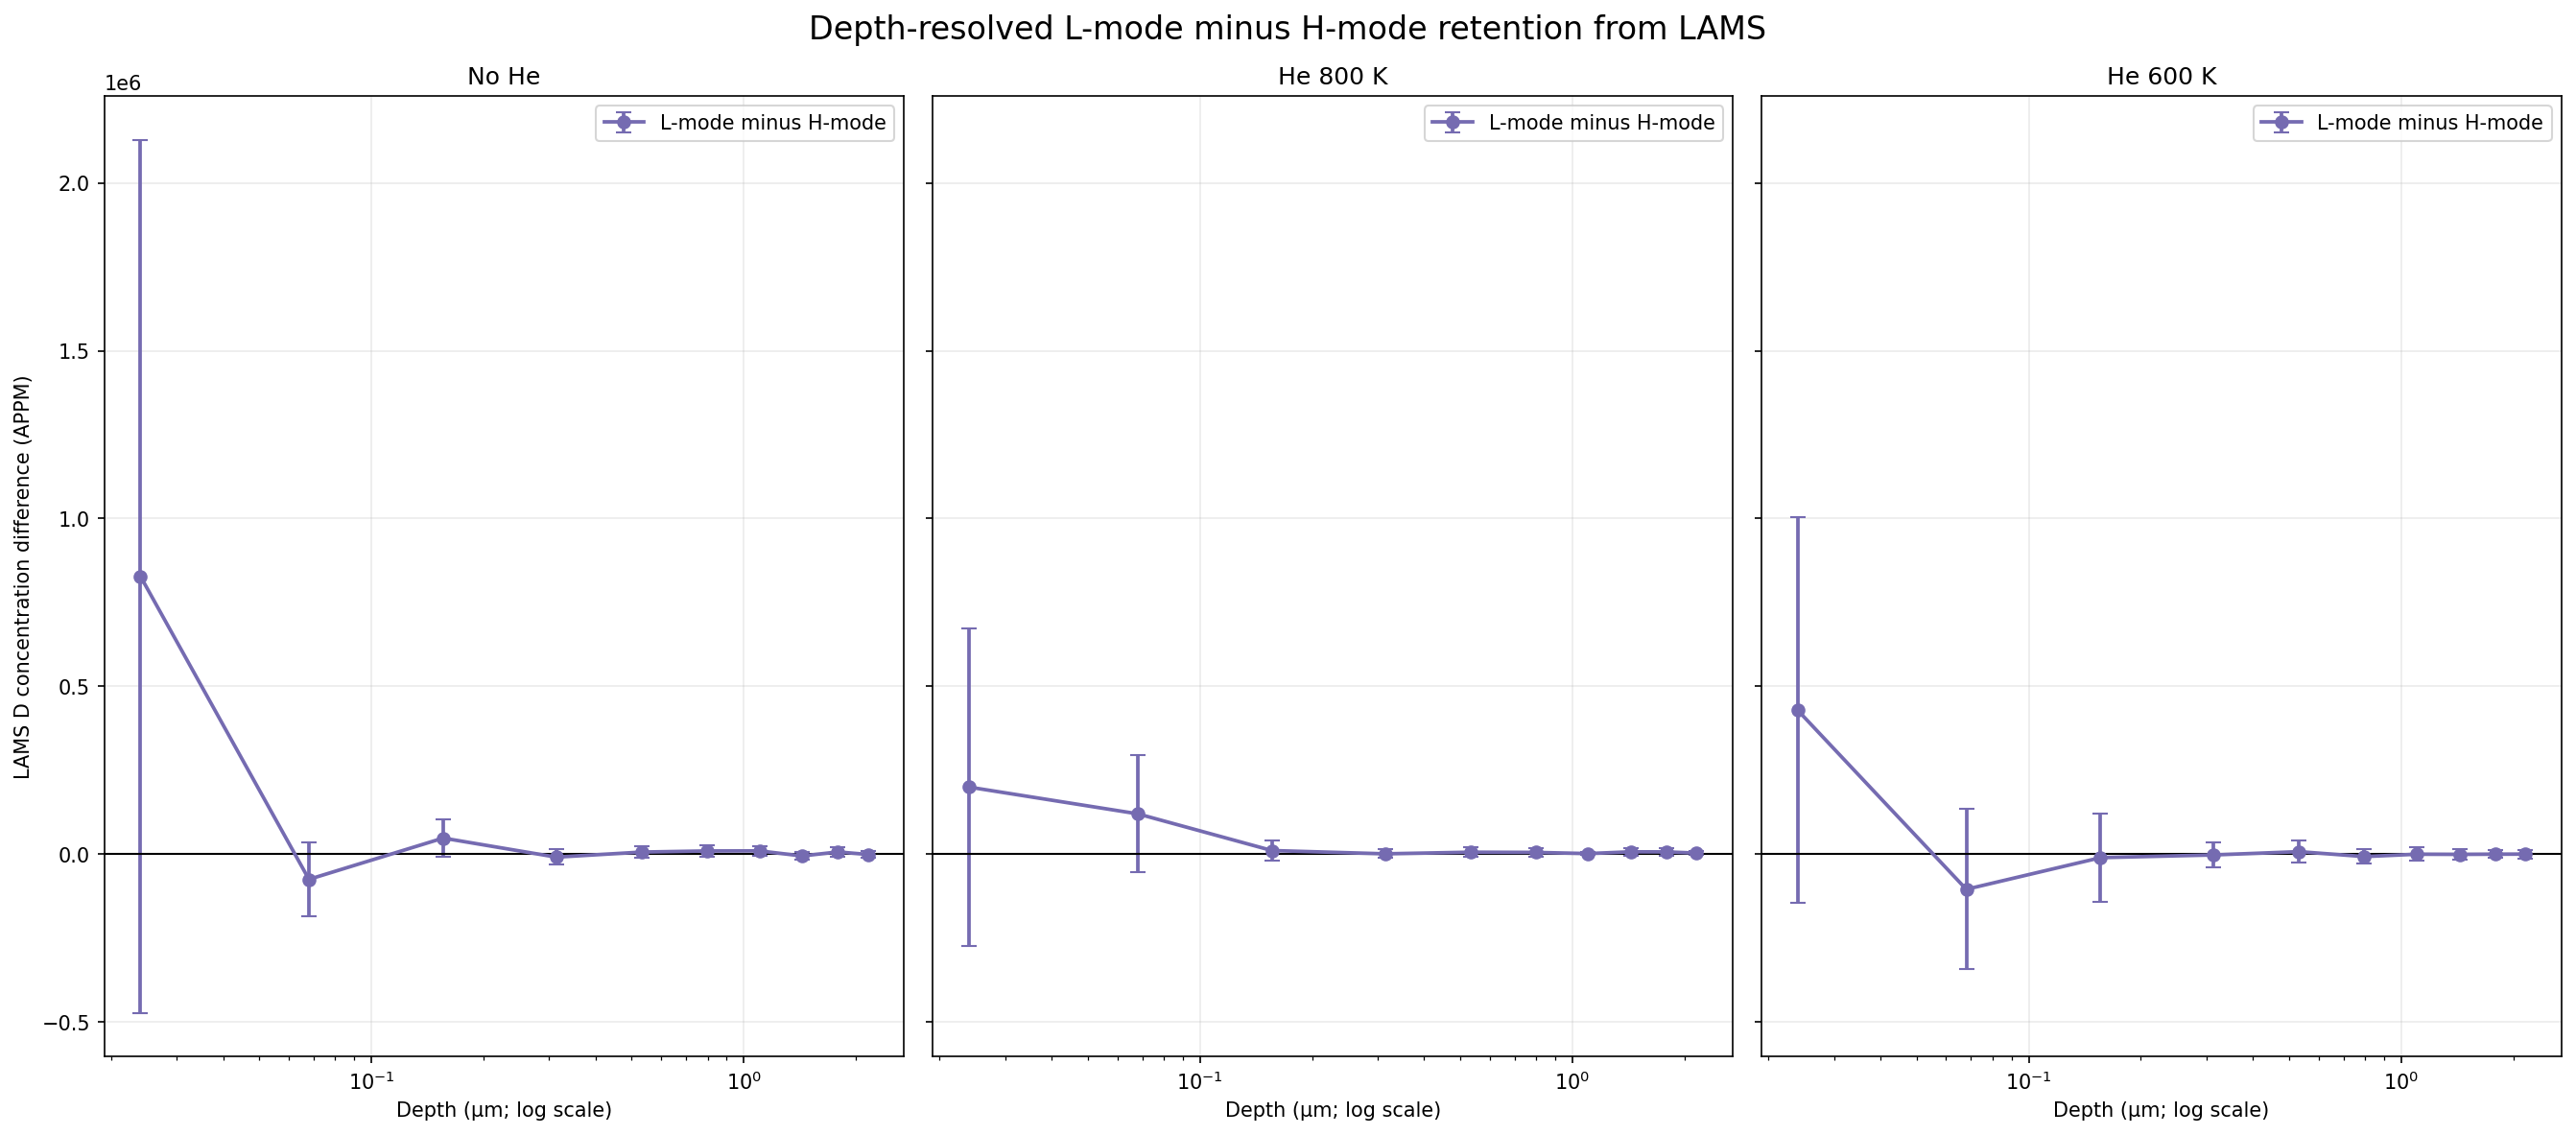

### Descriptive LAMS profile-area comparison

Integrating each measured LAMS profile over its 0.024–2.155 µm depth grid gives a descriptive APPM·µm profile area. This is useful for summarizing the profile but is **not a total areal density** :

| Helium pretreatment | H-mode profile area | L-mode profile area | L-mode change |
|---|---:|---:|---:|
| None | 33,415 APPM·µm | 58,365 APPM·µm | $+74.7\%\pm109.5$ percentage points |
| 800 K He | 16,544 APPM·µm | 39,021 APPM·µm | $+135.9\%\pm131.5$ percentage points |
| 600 K He | 56,190 APPM·µm | 56,193 APPM·µm | $+0.006\%\pm53.7$ percentage points |

These uncertainties were propagated from the reported pointwise LAMS standard deviations, assuming independent depth points. That assumption is only an approximation; shared calibration or fitting effects could correlate the points.

LAMS broadly supports an increase after 800 K pretreatment because all ten measured depths were higher in L-mode. Nevertheless, none of the individual depth differences exceeded one combined standard deviation. For the no-He and 600 K cases, the LAMS profile changes alternate in sign with depth and do not provide a resolved, method-independent retention increase.

## Uncertainty and strength of evidence

### ERDA

ERDA provides a standard deviation for each coupon. For the ratio $r=D_{\mathrm{L}}/D_{\mathrm{H}}$, I propagated the reported uncertainties as

$$
\sigma_r=r\sqrt{
\left(\frac{\sigma_{\mathrm{L}}}{D_{\mathrm{L}}}\right)^2+
\left(\frac{\sigma_{\mathrm{H}}}{D_{\mathrm{H}}}\right)^2
},
$$

assuming independent errors.

At the level of those reported instrumental errors, the L−H differences are:

- **No He** : 3.26 combined standard deviations;
- **800 K He** : 13.93 combined standard deviations;
- **600 K He** : 8.49 combined standard deviations.

Thus, ERDA resolves all three coupon-level differences relative to its own reported measurement errors.

### NRA

NRA supplies no numerical uncertainty in this delivery. Its L-mode increases are clear numerically, but formal error bars, confidence intervals, or significance levels cannot be calculated from the delivered data. The provider’s assessment that NRA is the most trustworthy technique does not imply zero uncertainty.

### LAMS

LAMS has large reported uncertainties, often comparable to or exceeding the measured values. No one of the 30 matched L−H depth differences exceeded one combined pointwise standard deviation. The integrated 800 K profile difference reached only about 1.26 combined standard deviations under the independent-point approximation.

The provider explicitly classifies LAMS as experimental and directs that it be treated as indicative rather than allowed to outweigh NRA or ERDA.

### Experimental-design uncertainty

The largest limitation is not an instrument error: **each helium-treatment–plasma-regime cell contains only one coupon** . Therefore:

- ERDA’s small measurement errors establish that the specific coupons differed beyond ERDA’s instrumental scatter.
- They do not establish the reproducibility of the L–H effect across tungsten coupons.
- Coupon-to-coupon variability cannot be estimated.
- The lack of replicate coupons means the instrumental-error $z$ values are not population-level treatment-effect tests.
- Surface and bulk temperatures during DIII-D exposure were not measured, so temperature differences cannot be ruled out as an additional contributor.

## Overall interpretation

1. **Most defensible result** : According to NRA, L-mode exposure produced higher total D retention than H-mode at all three helium-pretreatment levels: +26.6% without helium, +354.3% after 800 K helium exposure, and +100.3% after 600 K helium exposure.

2. **Independent areal-density support** : ERDA agrees on all three directions, giving +26.7%, +199.4%, and +63.3%, respectively. Its delivered instrumental uncertainties are small enough to resolve the coupon-level differences.

3. **Depth dependence** : NRA shows that the no-He increase was relatively strongest from 0.5–3 µm, whereas the large helium-pretreated increases were dominated in absolute magnitude by the first 0.5 µm.

4. **LAMS qualification** : LAMS supports a general L-mode increase most consistently for the 800 K pretreatment, where all ten depth points increased, but its large uncertainties prevent any individual depth difference from being resolved at one combined standard deviation.

5. **Causal limit** : The result is a comparison of the delivered L-mode and H-mode campaigns—not an isolated test of confinement regime. L-mode simultaneously had 67% higher particle flux, 16% higher fluence, 17% higher impact energy, and 35% lower heat flux.

## Data files

- [plasma_mode_conditions.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/plasma_mode_conditions.csv) — recorded H-mode and L-mode exposure conditions, ratios, and percentage changes.
- [total_retention_mode_comparison.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/total_retention_mode_comparison.csv) — matched NRA and ERDA totals, absolute changes, L/H ratios, and propagated ERDA uncertainties.
- [nra_depth_band_mode_comparison.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/nra_depth_band_mode_comparison.csv) — NRA comparisons for the 0–0.5 and 0.5–3 µm bands.
- [lams_depth_mode_comparison.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lams_depth_mode_comparison.csv) — all 30 matched LAMS depth-point differences, ratios, uncertainties, and standardized differences.
- [lams_profile_area_mode_comparison.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/lams_profile_area_mode_comparison.csv) — trapezoidally integrated LAMS profile descriptors and propagated uncertainties.
- [mode_retention_analysis_summary.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/mode_retention_analysis_summary.json) — machine-readable summary of the matched comparisons and diagnostics.
- [mode_retention_query_raw.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/mode_retention_query_raw.json) — raw FEDER materials query results, experimental design, provider guidance, exposure conditions, and attached-literature search results.

In [4]:
%%ask
Quantify changes in D retention with changes in DIII-D plasma conditions 
(L vs. H mode). Include both changes in the total D retention measured 
as well as D retention as a function of depth. As done previously, comment 
on differences in the answer based on the retention measurement technique 
that was used. 

## 4 — What this does not establish

A closing question about the limits of the dataset rather than its contents.


In [6]:
%%ask
Given these tungsten samples and the retention measurements delivered with
them, what would this analysis not be sufficient to claim, and what further
measurement would be needed?

I’ll verify the dataset’s design limitations and provider guidance, then distinguish unsupported claims from the measurement needed to support them.

I’m reading the materials skill to use the documented FEDER queries and preserve the dataset’s interpretation rules.

I’m checking the materials-skill learnings now so the query avoids known lakehouse and interpretation errors.

The skill confirms that single-coupon cells cannot establish reproducibility and that the attached papers must be searched before recommending a measurement.

I’m reading the literature-search instructions before querying the papers attached to this materials delivery.

...

I’m reading the paper passage about combining depth profiling with thermal desorption, which directly addresses the strongest missing endpoint.

The key distinction is now clear: TDS is the missing endpoint for whole-coupon inventory, while replication, temperature control, and microscopy answer different causal claims.

I’m confirming that the raw evidence, scope table, and recommendation table are all present in the working directory.

All checkable outputs are present. No script required an edit-and-retry cycle, so no new skill learning entry is warranted.

**Short answer** : These measurements support statements about the **specific coupons and the near-surface depth ranges analyzed** , but they do not establish a reproducible tungsten-wide treatment effect, a causal effect of confinement mode alone, a whole-coupon D inventory, or a helium-nanobubble transport mechanism. The most valuable single additional retention measurement would be **quantitative post-exposure thermal-desorption spectroscopy (TDS)** on matched replicate coupons; replication, direct temperature measurements, and microscopy would still be required for causal and mechanistic claims.

## What can safely be claimed

The defensible statement is narrowly experimental:

> The particular L-mode and H-mode coupons delivered different NRA, ERDA, and LAMS results under the recorded exposure packages.

The previous “total NRA retention” values require an important qualification: they are the sum of the delivered NRA bands from **0 to 3 µm** , not a demonstrated inventory of the entire tungsten coupon. Likewise, ERDA supplies one areal-density endpoint per coupon, but this delivery does not demonstrate that ERDA recovered or sampled all D throughout the coupon.

| Delivered technique | What it measures here | Delivered depth information | Main limitation |
|---|---|---|---|
| NRA | D areal density | 0–0.5 and 0.5–3 µm bands | Nothing deeper than 3 µm is represented; no numerical uncertainty was delivered |
| ERDA | One D areal-density result per coupon | Analysis depth is not specified in the lakehouse quantity metadata | Small reported instrumental uncertainty does not prove exhaustive whole-coupon recovery |
| LAMS | D concentration in APPM | Ten points from 0.024 to 2.155 µm | Not a directly comparable total inventory; provider classifies it as experimental, with large uncertainties |
| Post-exposure TDS | Not delivered | Would integrate releasable D throughout the heated coupon | No such post-exposure result is present in the delivery |

The post-exposure artifact catalogue contains the NRA/ERDA workbook and the LAMS workbook, but no post-exposure TDS result or post-exposure cross-sectional microscopy result.

## Claims this analysis is not sufficient to make

### 1. It cannot establish the whole-coupon D inventory

Calling the NRA sum or ERDA endpoint the **total D retained in the tungsten coupon** would go beyond the measurement.

- NRA ends at 3 µm.
- LAMS ends at 2.155 µm and reports concentration rather than integrated areal inventory.
- ERDA reports areal density, but the delivered metadata do not establish complete recovery of D at all depths.
- D below the analysis range would be missed.
- The methods also do not show how much D would be thermally released, at what temperature, or from which trapping states.

**Needed measurement** : Calibrated TDS with mass spectrometry, integrating the complete $D_2$ and HD release during a controlled heating ramp until desorption is complete. That would provide a whole-sample **thermally releasable inventory** and a desorption-temperature spectrum.

TDS would complement rather than replace the current methods:

- NRA/LAMS provide spatial information.
- TDS provides integrated release and information about trapping/release temperatures.
- If both are required, obtain the depth profile before TDS or use matched sacrificial coupons, because TDS is destructive with respect to the retained inventory.

Baldwin and Doerner used TDS together with transport modeling to investigate inward and outward D transport across a helium-affected tungsten surface. Their work also notes that an accurately measured pre-TDS depth profile can be supplied to the transport model. That is a particularly useful combination for these samples, but their results are contextual evidence from different targets—not measurements of the present coupons.

### 2. It cannot establish a reproducible helium-treatment or plasma-mode effect

Every one of the **nine experimental design cells contains one coupon** . This includes each of the six combinations of:

- no He, 600 K He, or 800 K He pretreatment; and
- H-mode or L-mode DIII-D exposure.

Consequently, differences between cells cannot be separated from coupon-to-coupon variability. ERDA’s small reported instrumental uncertainties establish that the measured values on two particular coupons differ relative to ERDA measurement scatter; they do not estimate biological-style—or, here, material-sample—replication variance.

**Needed experiment** : Multiple independently prepared coupons in every treatment-by-mode cell, taken through the complete fabrication, pretreatment, DIII-D exposure, and retention-analysis sequence. NRA or ERDA should be repeated on every replicate, with TDS preferably included for whole-coupon inventory.

A repeat scan of the same coupon would characterize instrumental repeatability, but it would **not** replace independent coupon replication.

### 3. It cannot claim that confinement mode itself caused the L–H difference

The L-mode and H-mode campaigns simultaneously differed in particle flux, fluence, impact energy, heat flux, exposure duration, $T_e$, and $n_e$. In addition, the provider explicitly reports that neither surface nor bulk coupon temperature was measured during DIII-D exposure.

Because D diffusion, trapping, and release in tungsten are strongly temperature-dependent, the absence of sample temperature prevents a clean attribution of the observed retention difference to confinement regime.

**Needed measurements and design** :

1. Direct, time-resolved coupon surface temperature, preferably using a calibrated pyrometer or infrared measurement with known emissivity.
2. A bulk or rear-face temperature measurement, such as a thermocouple where technically feasible.
3. Matched or factorial exposures in which confinement mode is varied while fluence, flux, impact energy, heat load, exposure time, and coupon temperature are held constant or independently varied.

Without that design, the supported claim is about the two **exposure packages** , not about “L-mode physics versus H-mode physics” in isolation.

### 4. It cannot establish the physical mechanism behind the helium effect

The retention data show inventory differences and some depth redistribution. They do not directly demonstrate that:

- a helium nanobubble layer existed on these particular post-DIII-D coupons;
- its bubble size, density, porosity, or depth differed between 600 and 800 K pretreatments;
- helium changed D diffusivity or solubility;
- the layer acted as a permeation barrier;
- D recycling increased; or
- any particular trapping site caused the observed inventory.

Several mechanisms can produce a similar final retention profile. Baldwin and Doerner distinguished altered transport from altered recycling using controlled exposure sequences, TDS release spectra, and TMAP modeling; even then, their interpretation required changes in both near-surface transport properties and penetrating D flux.

**Needed measurements** :

- **Direct post-exposure cross-sectional TEM** to quantify nanobubble size, number density, depth distribution, and near-surface damage. FIB can prepare the cross section, but conventional SEM alone may not resolve approximately nanometre-scale bubbles.
- Alternatively, a validated nanobubble-sensitive scattering measurement could quantify the bubble population.
- **TDS plus transport modeling or a direct permeation experiment** to constrain migration and release behavior.
- **Time-resolved $D_\alpha$ and $D_2$ recycling measurements** to test recycling independently of retained inventory.

The original experiment proposal planned surface SEM, cross-sectional FIB/SEM, and time-resolved recycling analysis, but those post-exposure results are not part of the delivered retention dataset.

### 5. It cannot establish an ELM-specific retention or recycling effect

The retention values are post-mortem, campaign-integrated endpoints. They do not indicate which fraction of the final inventory was accumulated or released:

- during ELMs;
- between ELMs; or
- during other portions of the discharges.

**Needed measurement** : Spatially and temporally resolved $D_\alpha$ and $D_2$ emission synchronized to individual ELM times, combined with matched post-exposure retention measurements. That would connect transient recycling to the final inventory.

### 6. It cannot be directly generalized to reactor tritium inventory

These are D measurements after sequential He pretreatment and DIII-D D exposure. They do not directly reproduce simultaneous D–T–He exposure, neutron-created defects, reactor operating temperatures, or long-duration fluence.

**Needed experiment** : Mixed-species, reactor-relevant exposures with controlled temperature and displacement damage, followed by isotope-resolved retention and TDS measurements. Direct tritium experiments would be required for a quantitative tritium-inventory claim.

## Highest-priority next experiment

If the immediate question is **“How much D did each coupon retain in total?”** , the best next endpoint is:

> **Quantitative post-exposure TDS of independently replicated, matched coupons, integrating calibrated $D_2$ and HD release through complete desorption.**

A strong measurement sequence would be:

1. Prepare several independent coupons per helium-temperature and plasma-mode cell.
2. Measure surface and bulk temperature during DIII-D exposure.
3. Obtain NRA or another quantitative depth profile before heating.
4. Perform calibrated TDS on the same coupon or a matched replicate.
5. Obtain cross-sectional TEM on another matched replicate.
6. Where mechanism is the goal, add synchronized recycling or permeation measurements.

That combination separates four questions that the current delivery cannot resolve with one endpoint: **where the D is, how much is present overall, how reproducible the effect is, and why the inventory changed** .

## Reference

M.J. Baldwin and R.P. Doerner (2017) Hydrogen isotope transport across tungsten surfaces exposed to a fusion relevant He ion fluence. Nuclear Fusion 57 076031 doi:10.1088/1741-4326/aa70b1

## Data files

- [retention_measurement_scope.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/retention_measurement_scope.csv) — method-by-method depth coverage, uncertainty availability, sample counts, and whole-coupon limitations.
- [claim_limits_and_needed_measurements.csv](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/claim_limits_and_needed_measurements.csv) — unsupported claims, reasons they are unsupported, and the measurement or design needed for each.
- [claim_limits_evidence_summary.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/claim_limits_evidence_summary.json) — sample counts, design-cell sizes, method depth ranges, and delivered post-exposure artifact summary.
- [claim_limits_query_raw.json](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/claim_limits_query_raw.json) — raw FEDER design, method, provider-guidance, document-search, and attached-literature results.
- [proposal_document_text.txt](/home/jovyan/work/_User-Persistent-Storage_CephBlock_/deep_tok/_argus_feder_materials_he_effect_v3_jupyterhub_sage_/proposal_document_text.txt) — searchable text of the experiment proposal, including the planned post-exposure analysis and recycling diagnostics.